# Setup

1. Install conda
2. `conda create --name cogs508`
3. `conda activate cogs508`
4. `conda install python=3.12`
5. `conda install -c conda-forge pandas`
6. `conda install seaborn -c conda-forge`
7. `pip install notebook`

Select ipynotebook kernel (cogs508) from top-right.

# Stroop

## Imports

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import uuid
import matplotlib.pyplot as plt

## Experiment Design

We will use the following variables and consider the design of the experiment before beginning with the anaylsis.

### Dependents
- Response time
- Accuracy

### Independents
- Language [tr,eng]
- Duration [short, long]
- Congruency [1, 0]
- Color [R, G, B] (we will average over this if it's not expected to change dependent measurements)

### Trials
Each condition appears 5 times under each combination of independent variable values. 
- Language [tr,eng] x Duration [short, long] x Congruency [1, 0] x Color [R,G, B] x Repeat 5 times
-  2 x 2 x 2 x 3 x 5 = 120

## Data Loading

We keep the untidy data as separate csv files in a data folder. Below we get the files that end with a .csv extension in that folder, and append file relative paths to a list (`file_list`).

In [2]:
from pathlib import Path

data_dir = Path("data")

file_list = []
for f in data_dir.glob("*.csv"):
	file_list.append(f)

Number of participants

In [3]:
n_participants = len(file_list)
n_participants

14

A dataframe for a single participant

In [4]:
df = pd.read_csv("data/eylem _stroop_group_2026-05-07_12h56.41.935.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   instructions.started     1 non-null      float64
 1   instructions.stopped     1 non-null      float64
 2   participant              122 non-null    str    
 3   session                  122 non-null    int64  
 4   age (years)              122 non-null    int64  
 5   date                     122 non-null    str    
 6   expName                  122 non-null    str    
 7   psychopyVersion          122 non-null    str    
 8   OS                       122 non-null    str    
 9   frameRate                122 non-null    float64
 10  trial.started            60 non-null     float64
 11  trial.stopped            60 non-null     float64
 12  resp.keys                60 non-null     str    
 13  resp.corr                60 non-null     float64
 14  resp.rt                  60 non-null 

## Data Tidying

Our goal is to keep a tidy version of the whole dataset with each row as an observation and each variable in a column.

- In the end we should have 14 x 120 rows (participants x trials).
- For each observation from a participant (row) we should be able to query following information
	- properties about the stimulus
		- duration condition
		- language condition
		- whether word coloring is congruent with the text
		- color of the word (if interested)
	- variables about the participant's answers
		- is the answer correct
		- the response time


Inspecting the dataframe we see that the duration condition is separated by entries in different columns. This is actually against tidy data principles. Our first aim will be having a duration condition column in our tidy dataframe. We can see that it this difference is coded in column names. The no max duration threshold (long) is indicated with `nomax` keyword and the short duration ones are indicated with `min` keyword (e.g. `resp.rt` and `resp_min.rt` corresponds to the response times under long and short duration conditions, respectively). If you are the designer of the experiment you can understand this quickly, but if you are analyzing others' data you might need to discover this yourself. We did the second part and realized that half of the response times were missing in either of the columns.

The first row is from the instruction part:

In [5]:
df.head(3)

,instructions.started,instructions.stopped,participant,session,age (years),date,expName,psychopyVersion,OS,frameRate,...,resp_min.corr,resp_min.rt,resp_min.duration,trials_min.thisRepN,trials_min.thisTrialN,trials_min.thisN,trials_min.thisIndex,trials_min.ran,thanks.started,thanks.stopped
0,0.0002,9.2854,eylem,1,25,2026-05-07_12h56.41.935,stroop_group,2026.1.3,Win32,144.927536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,eylem,1,25,2026-05-07_12h56.41.935,stroop_group,2026.1.3,Win32,144.927536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,eylem,1,25,2026-05-07_12h56.41.935,stroop_group,2026.1.3,Win32,144.927536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


And the last row is for the thanks section of the experiment. (below shown with the last 3 rows, last 4 columns)

In [6]:
df.tail(3).iloc[:,-4:]

,trials_min.thisIndex,trials_min.ran,thanks.started,thanks.stopped
119,11.0,1.0,NaN,NaN
120,8.0,1.0,NaN,NaN
121,NaN,NaN,192.2115,194.2069


So we remove the first and last row completely: (`iloc[1:-1]` slices out the first and last rows, and `reset_index` makes the index continuous again.)

In [7]:
df = df.iloc[1:-1].reset_index(drop=True)

Now we expect each column to contain 120 rows. We want to keep duration condition in a column. We've seen that the first 60 rows were collected under no maximum duration condition (i.e. long duration condition), and the last 60 were collected under the short duration condition. So we repeat a corresponding string 60 times.

In [8]:
duration_condition_values = np.concat([np.repeat("long", 60), np.repeat("short", 60)]).tolist()

Next we want to extract the language condition values below. We see that the language value is shared regardless of the duration block.

In [9]:
# get language values as a list
language_condition_values = df["language"].values.tolist()

Now we need to keep the congruency condition as well. Similarly, this is also given in a single column. The letter colors as well.

In [10]:
congruency_condition_values = df["congruent"].values.tolist()
stimulus_letter_color_values = df["letterColor"].values.tolist()

However, response times were recorded under different columns based on the duration condition. We need to merge these (i.e.`resp.rt` and `resp_min.rt`)

In [11]:
df[["resp.rt", "resp_min.rt"]]

,resp.rt,resp_min.rt
0,0.6230,NaN
1,0.5625,NaN
2,1.0323,NaN
3,1.5079,NaN
4,1.7797,NaN
...,...,...
115,NaN,0.4834
116,NaN,0.6672
117,NaN,0.8249
118,NaN,0.4928


So, we'll keep these values simply in one column, named `response_time`. The first 60 from `resp.rt` and the remaining from the `resp_min.rt` columns.

In [12]:
response_time_values = np.concatenate(
    [df["resp.rt"][:60].values, df["resp_min.rt"][60:].values]
).tolist()

Lastly we need whether the participant answer was correct. The column case is similar to the response time. 

In [13]:
correct_response_given_values = np.concatenate(
    [df["resp.corr"][:60].values, df["resp_min.corr"][60:].values]
).tolist()

In [14]:
len(correct_response_given_values)

120

Finally we will create the tidy dataframe. We also need to assign a unique identifier for each participant, and repeat that value for all samples. For generating unique ids we'll use the `uuid` package.

In [15]:
# uuid imported at the top
short_id = str(uuid.uuid4())[:8]
short_id = np.repeat(short_id, 120)

In the end we will loop over the file list and apply the above steps to each participant. We will keep a participant's dataframe in a list, and combine to get the final tidy dataframe.

In [17]:
# this will not change
duration_condition_values = np.concatenate(
    [np.repeat("long", 60), np.repeat("short", 60)]
).tolist()

clean_df_list = []
for f in file_list:
    # read df
    df = pd.read_csv(f)
    # drop last and first rows
    df = df.iloc[1:-1].reset_index(drop=True)
    # get variables
    language_condition_values = df["language"].values.tolist()
    congruency_condition_values = df["congruent"].values.tolist()
    stimulus_letter_color_values = df["letterColor"].values.tolist()
    response_time_values = np.concatenate(
        [df["resp.rt"][:60].values, df["resp_min.rt"][60:].values]
    ).tolist()
    correct_response_given_values = np.concatenate(
        [df["resp.corr"][:60].values, df["resp_min.corr"][60:].values]
    ).tolist()
    # generate an id
    short_id = np.repeat(str(uuid.uuid4())[:8], 120)
    # create tidy df
    df_clean = pd.DataFrame({
        "participant_id": short_id,
        "language": language_condition_values,
        "duration": duration_condition_values,
        "congruency": congruency_condition_values,
        "color": stimulus_letter_color_values,
        "response_time": response_time_values,
        "response_correct": correct_response_given_values,
    })
    clean_df_list.append(df_clean)

tidy_df = pd.concat(clean_df_list, ignore_index=True)
tidy_df

,participant_id,language,duration,congruency,color,response_time,response_correct
0,4dedb84c,EN,long,0.0,blue,2.282664,1.0
1,4dedb84c,EN,long,1.0,red,0.645842,1.0
2,4dedb84c,TR,long,0.0,blue,1.327088,1.0
3,4dedb84c,TR,long,1.0,green,0.483595,1.0
4,4dedb84c,EN,long,1.0,green,0.649838,1.0
...,...,...,...,...,...,...,...
1675,3ceba04f,EN,short,0.0,red,0.483400,1.0
1676,3ceba04f,EN,short,0.0,green,0.667200,1.0
1677,3ceba04f,TR,short,1.0,blue,0.824900,1.0
1678,3ceba04f,TR,short,0.0,red,0.492800,1.0


In [40]:
tidy_df.to_csv("tidy_df.csv")

## Plotting

In this section we'll try to make sense of experimental manipulations' effect on measurements. We will use seaborn library.

## Response Times

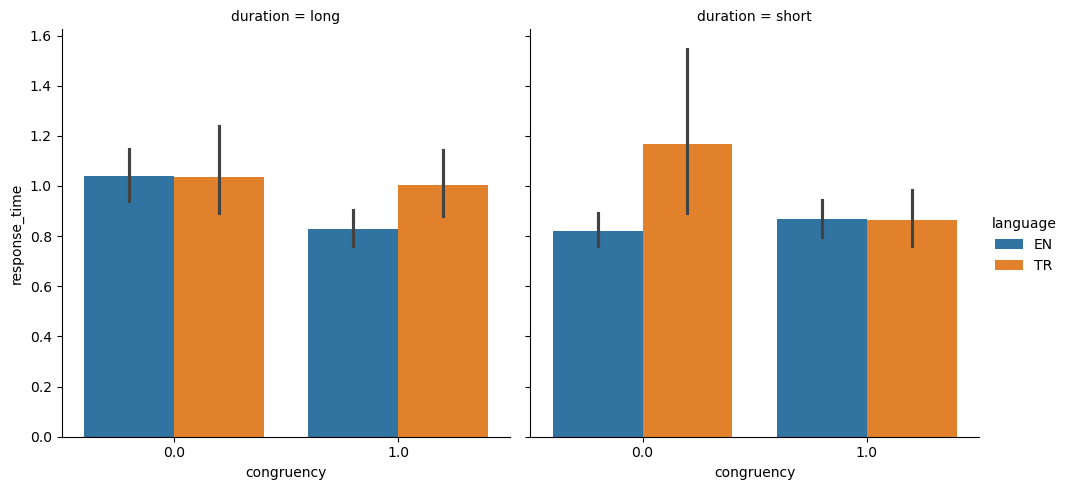

In [35]:
sns.catplot(data=tidy_df, x="congruency", y="response_time", hue="language", col="duration", kind="bar", errorbar="ci");

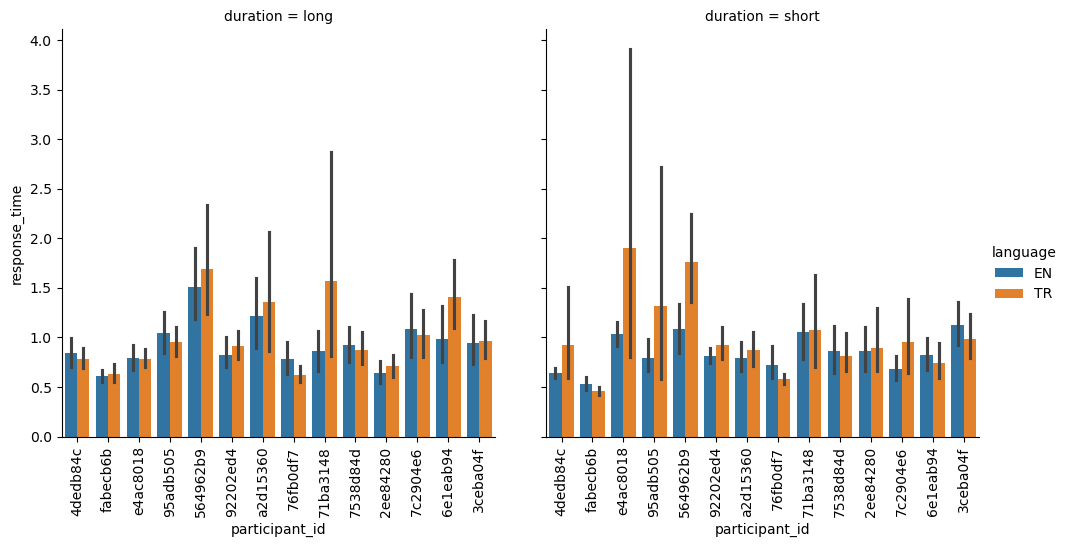

In [37]:
g = sns.catplot(data=tidy_df, x="participant_id", y="response_time", hue="language", col="duration", kind="bar", errorbar="ci")
g.set_xticklabels(rotation=90)

## Accuracies

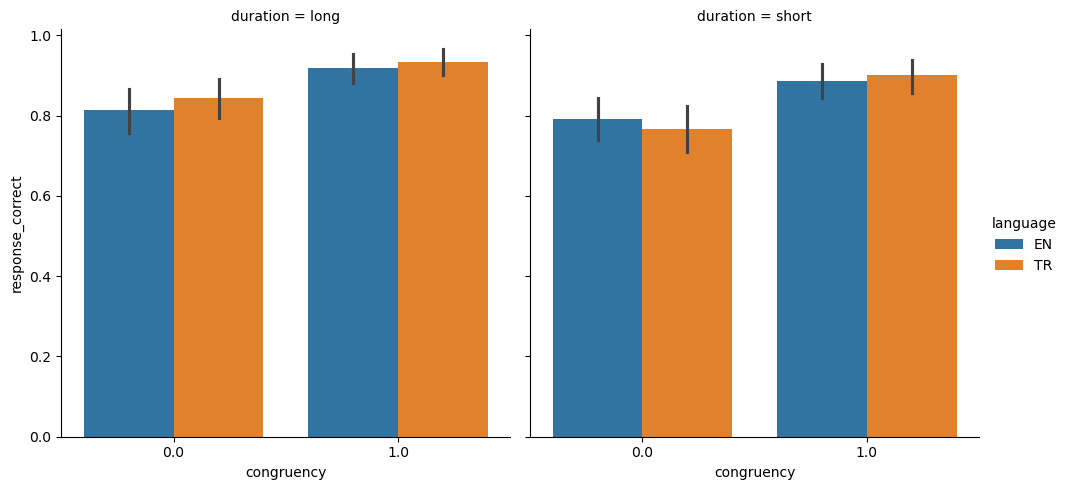

In [39]:
g = sns.catplot(data=tidy_df, x="congruency", y="response_correct", hue="language", col="duration", kind="bar", errorbar="ci")

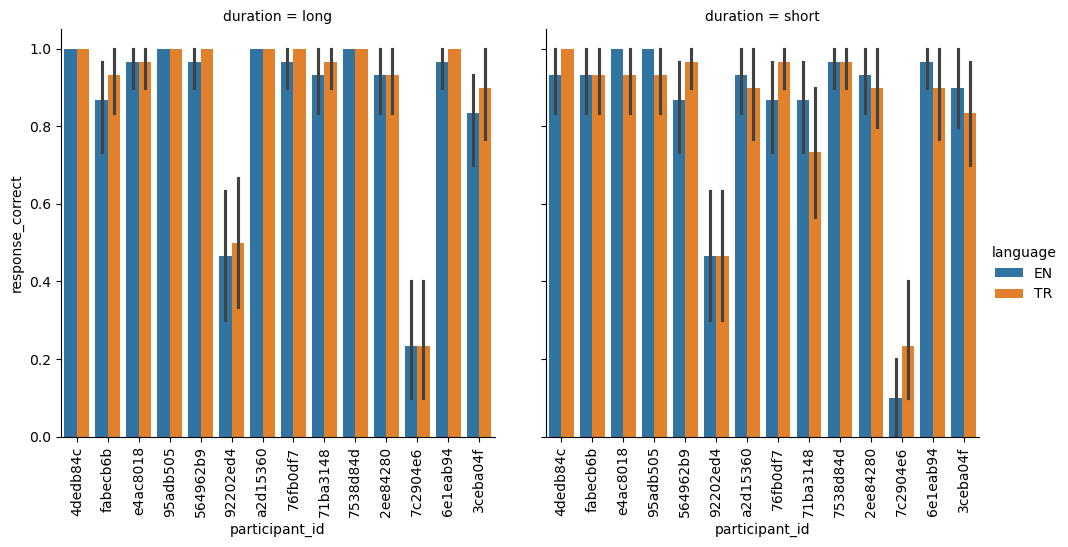

In [38]:
g = sns.catplot(data=tidy_df, x="participant_id", y="response_correct", hue="language", col="duration", kind="bar", errorbar="ci")
g.set_xticklabels(rotation=90)